# Task 1: Data Understanding and Visualization
### Question
1. Load and visualize images from a dataset stored in directories, where each subdirectory represents a class.


In [26]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [27]:
zip_path = "/content/drive/MyDrive/AI and Machine Learning/Week 5/FruitinAmazon.zip"

In [28]:
import zipfile

extract_path = "/content/dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [29]:
import os

print(os.listdir("/content/dataset"))

['FruitinAmazon']


In [30]:
print(os.listdir("/content/dataset/FruitinAmazon"))

['test', 'train']


In [31]:
import os
import random
import zipfile
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.models import load_model
from sklearn.metrics import classification_report

Classes: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


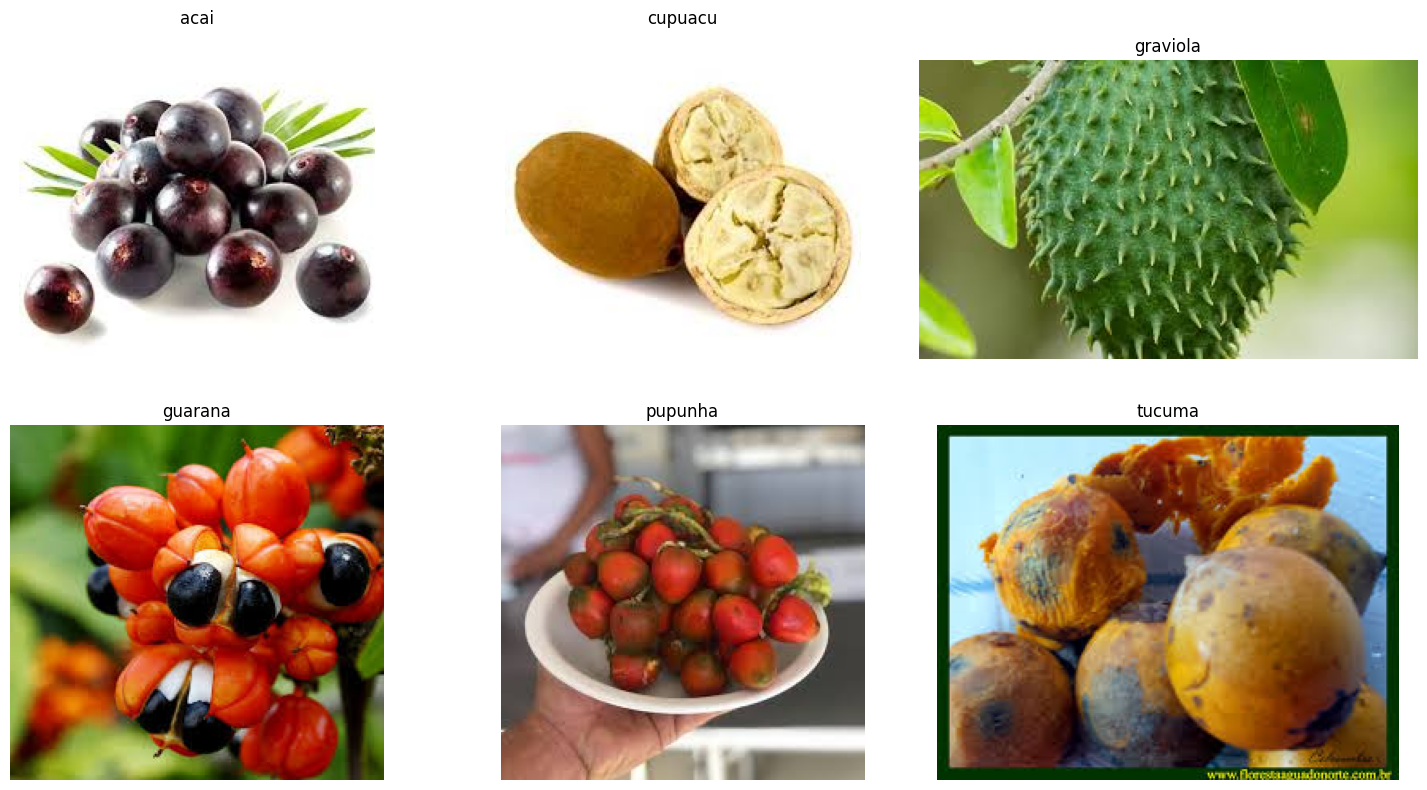

In [32]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image

# Path to training data
train_dir = "/content/dataset/FruitinAmazon/train"

# Get class folder names
class_names = [folder for folder in os.listdir(train_dir)
               if os.path.isdir(os.path.join(train_dir, folder))]
class_names.sort()

print("Classes:", class_names)

# Pick one random image from each class
sample_images = []
for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)
    image_files = [img for img in os.listdir(class_path)
                   if img.lower().endswith((".jpg", ".jpeg", ".png"))]

    if image_files:
        chosen_image = random.choice(image_files)
        sample_images.append((class_name, os.path.join(class_path, chosen_image)))

# Display images in 2 rows
num_images = len(sample_images)
rows = 2
cols = (num_images + 1) // 2

plt.figure(figsize=(15, 8))

for i, (class_name, image_path) in enumerate(sample_images):
    img = Image.open(image_path)
    plt.subplot(rows, cols, i + 1)
    plt.imshow(img)
    plt.title(class_name)
    plt.axis("off")

plt.tight_layout()
plt.show()

## Observation
The dataset is arranged in a class-based directory structure, where each folder contains images of one fruit category. After displaying one random image from each class, it can be observed that the fruit classes differ in color, shape, texture, and background. Some classes may look visually similar, while others are clearly distinct. This variation is useful because it helps the CNN learn different visual patterns, but it can also make classification more difficult when fruits have similar appearances.

# Task 1 (Part 2): Check for Corrupted Images

### Questions
2. Write a script that checks whether the images in the train directory are valid. If a corrupted image is found, remove it and print its path. If none are found, print:

In [33]:
import os
from PIL import Image

train_dir = "/content/dataset/FruitinAmazon/train"

corrupted_images = []

for class_name in os.listdir(train_dir):
    class_path = os.path.join(train_dir, class_name)

    if os.path.isdir(class_path):
        for file_name in os.listdir(class_path):
            image_path = os.path.join(class_path, file_name)

            try:
                with Image.open(image_path) as img:
                    img.verify()
            except (IOError, SyntaxError, OSError):
                corrupted_images.append(image_path)
                os.remove(image_path)
                print(f"Removed corrupted image: {image_path}")

if len(corrupted_images) == 0:
    print("No Corrupted Images Found.")
else:
    print(f"Total corrupted images removed: {len(corrupted_images)}")

No Corrupted Images Found.


## Explanation
This code goes through each class folder and checks every image file using PIL.Image.open() and verify(). If an image is corrupted, it raises an error, and the file is deleted. This step is important because corrupted images can cause errors during training or preprocessing.

# Task 2: Loading and Preprocessing Image Data in Keras
### Question
3. Load and preprocess image data. Apply resizing, batching, normalization, and a validation split.

In [34]:
import tensorflow as tf

# Dataset paths
train_dir = "/content/dataset/FruitinAmazon/train"
test_dir = "/content/dataset/FruitinAmazon/test"

# Parameters
img_height = 128
img_width = 128
batch_size = 16
validation_split = 0.2
seed = 123

# Normalization layer
rescale = tf.keras.layers.Rescaling(1./255)

# Training dataset
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=True,
    validation_split=validation_split,
    subset='training',
    seed=seed
)

# Validation dataset
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=False,
    validation_split=validation_split,
    subset='validation',
    seed=seed
)

# Test dataset
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=False
)

# Get class names BEFORE map/prefetch
class_names = train_ds.class_names
num_classes = len(class_names)

# Normalize datasets
train_ds = train_ds.map(lambda x, y: (rescale(x), y))
val_ds = val_ds.map(lambda x, y: (rescale(x), y))
test_ds = test_ds.map(lambda x, y: (rescale(x), y))

# Performance optimization
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)

print("Class Names:", class_names)
print("Number of Classes:", num_classes)

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.
Found 30 files belonging to 6 classes.
Class Names: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']
Number of Classes: 6


## Explanation
This code loads the images directly from class-wise folders. The images are resized to 128 x 128, grouped into batches of 16, and normalized to values between 0 and 1 using a rescaling layer. The training directory is split into training and validation sets using an 80:20 ratio. This matches the preprocessing method explained in the worksheet.

# Task 3: Implement a CNN Model
### Question

Implement a CNN using the given architecture:

- Conv2D with 32 filters,kernel size (3,3), padding same, stride 1
- ReLU activation
- MaxPooling (2,2), stride 2
- Conv2D with 32 filters, kernel size (3,3), padding same, stride 1
- ReLU activation
- MaxPooling (2,2), stride 2
- Flatten
- Dense layers with 64 and 128 neurons
- Output layer with number of classes

In [35]:

model = models.Sequential([
    layers.Conv2D(32, (3, 3), strides=1, padding='same', activation='relu',
                  input_shape=(img_height, img_width, 3)),
    layers.MaxPooling2D(pool_size=(2, 2), strides=2),

    layers.Conv2D(32, (3, 3), strides=1, padding='same', activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2), strides=2),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(128, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │     2,097,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,116,454 (8.07 MB)

 Trainable params: 2,116,454 (8.07 MB)

 Non-trainable params: 0 (0.00 B)

## Explanation
The model starts with two convolutional layers to extract image features, followed by max pooling layers to reduce spatial size and computation. The flattened output is then passed through two dense layers with 64 and 128 neurons before reaching the final softmax output layer, which predicts the fruit class. This follows the worksheet’s required structure.

# Task 4: Compile the Model
### Question
Compile the model using an appropriate optimizer, loss function, and evaluation metric.

In [36]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Task 4: Train the Model

In [37]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

checkpoint = ModelCheckpoint(
    "best_model.h5",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True,
    verbose=1
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=250,
    callbacks=[checkpoint, early_stopping]
)

Epoch 1/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 241ms/step - accuracy: 0.1622 - loss: 1.8064
Epoch 1: val_accuracy improved from None to 0.00000, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 348ms/step - accuracy: 0.1389 - loss: 1.8204 - val_accuracy: 0.0000e+00 - val_loss: 1.8786
Epoch 2/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 248ms/step - accuracy: 0.2149 - loss: 1.6590
Epoch 2: val_accuracy improved from 0.00000 to 0.16667, saving model to best_model.h5



Epoch 2: finished saving model to best_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 315ms/step - accuracy: 0.2361 - loss: 1.6368 - val_accuracy: 0.1667 - val_loss: 1.6386
Epoch 3/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 226ms/step - accuracy: 0.4288 - loss: 1.4276
Epoch 3: val_accuracy improved from 0.16667 to 0.38889, saving model to best_model.h5



Epoch 3: finished saving model to best_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 297ms/step - accuracy: 0.4722 - loss: 1.3435 - val_accuracy: 0.3889 - val_loss: 1.4256
Epoch 4/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 248ms/step - accuracy: 0.7892 - loss: 1.0255
Epoch 4: val_accuracy improved from 0.38889 to 0.55556, saving model to best_model.h5



Epoch 4: finished saving model to best_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 306ms/step - accuracy: 0.7639 - loss: 0.9876 - val_accuracy: 0.5556 - val_loss: 0.9622
Epoch 5/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 411ms/step - accuracy: 0.9014 - loss: 0.6030
Epoch 5: val_accuracy improved from 0.55556 to 0.66667, saving model to best_model.h5



Epoch 5: finished saving model to best_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 503ms/step - accuracy: 0.8611 - loss: 0.6147 - val_accuracy: 0.6667 - val_loss: 0.7669
Epoch 6/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 407ms/step - accuracy: 0.8965 - loss: 0.4223
Epoch 6: val_accuracy improved from 0.66667 to 0.83333, saving model to best_model.h5



Epoch 6: finished saving model to best_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 507ms/step - accuracy: 0.8889 - loss: 0.4047 - val_accuracy: 0.8333 - val_loss: 0.7503
Epoch 7/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 254ms/step - accuracy: 0.9427 - loss: 0.2958
Epoch 7: val_accuracy improved from 0.83333 to 0.94444, saving model to best_model.h5



Epoch 7: finished saving model to best_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 313ms/step - accuracy: 0.9167 - loss: 0.3141 - val_accuracy: 0.9444 - val_loss: 0.3116
Epoch 8/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 243ms/step - accuracy: 0.9781 - loss: 0.1896
Epoch 8: val_accuracy did not improve from 0.94444
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 278ms/step - accuracy: 0.9583 - loss: 0.2036 - val_accuracy: 0.8333 - val_loss: 0.5817
Epoch 9/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 234ms/step - accuracy: 0.9510 - loss: 0.1472
Epoch 9: val_accuracy did not improve from 0.94444
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 280ms/step - accuracy: 0.9583 - loss: 0.1615 - val_accuracy: 0.8333 - val_loss: 0.5653
Epoch 10/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 227ms/step - accuracy: 1.0000 - loss: 0.0452
Epoch 10: val_accuracy did not improve from 0.94444
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 273ms/step - accuracy: 1.0000 - loss: 0.0533 - val_accuracy: 0.9444 - val_loss: 0.2417
Epoch 11/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 240ms/step - accuracy: 1.0000 - loss: 0.

# Task 5: Evaluate the Model
### Question

Evaluate the model on the test dataset using model.evaluate() to obtain test loss and test accuracy.

In [38]:
test_loss, test_accuracy = model.evaluate(test_ds)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.6000 - loss: 1.0522
Test Loss: 1.052215576171875
Test Accuracy: 0.6000000238418579


# Task 6: Save and Load the Model
### Questions
Save the trained model to an .h5 file, load it again, and re-evaluate it on the test dataset.

In [39]:
from tensorflow.keras.models import load_model

# Save model
model.save("fruit_classifier_model.h5")
print("Model saved successfully.")

# Load model
loaded_model = load_model("fruit_classifier_model.h5")
print("Model loaded successfully.")

# Re-evaluate loaded model
loaded_test_loss, loaded_test_accuracy = loaded_model.evaluate(test_ds)

print("Loaded Model Test Loss:", loaded_test_loss)
print("Loaded Model Test Accuracy:", loaded_test_accuracy)

Model saved successfully.


Model loaded successfully.
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.6000 - loss: 1.0522
Loaded Model Test Loss: 1.052215576171875
Loaded Model Test Accuracy: 0.6000000238418579


# Task 7: Predictions and Classification Report
### Questions
Use model.predict() to make predictions on test images, convert the predicted probabilities using np.argmax(), and generate a classification report using classification_report.

In [40]:
import numpy as np
from sklearn.metrics import classification_report

y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = loaded_model.predict(images)
    predicted_labels = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_labels)

report = classification_report(y_true, y_pred, target_names=class_names)
print("Classification Report:\n")
print(report)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step
Classification Report:

              precision    recall  f1-score   support

        acai       0.71      1.00      0.83         5
     cupuacu       1.00      0.40      0.57         5
    graviola       0.71      1.00      0.83         5
     guarana       0.00      0.00      0.00         5
     pupunha       0.57      0.80      0.67         5
      tucuma       0.29      0.40      0.33         5

    accuracy                           0.60        30
   macro avg       0.55      0.60      0.54        30
weighted avg       0.55      0.60      0.54        30



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


# Training and Validation Graphs

# Graphs showing training and validation accuracy and loss as part of the expected deliverables.

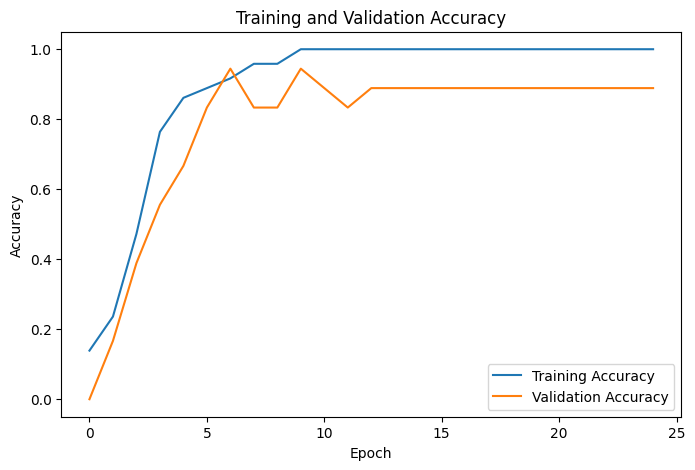

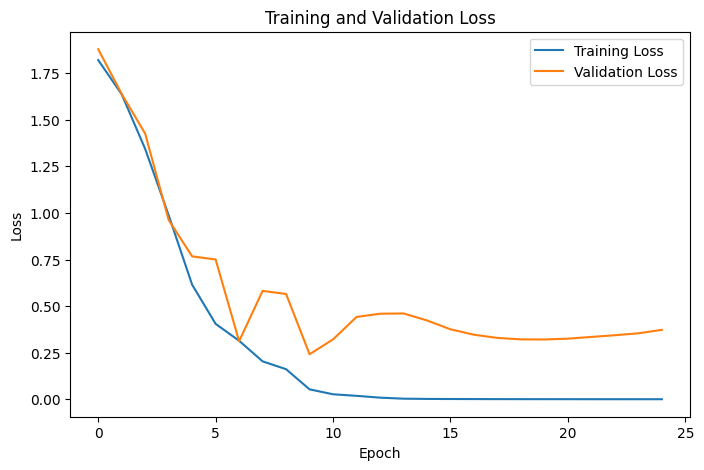

In [41]:
import matplotlib.pyplot as plt

# Plot accuracy
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.show()

# Plot loss
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()